
# Snore vs Non‑Snore — End‑to‑End CNN (No YAMNet)
This notebook keeps your **data augmentation** the same (noise mixing from ESC‑50 at random SNRs) but **skips YAMNet**.
We train a compact **2D‑CNN** on **log‑mel spectrograms** extracted directly from audio.


In [ ]:

!pip -q install librosa soundfile noisereduce kaggle tqdm scikit-learn matplotlib tensorflow


In [ ]:

from google.colab import drive, files
drive.mount('/content/drive')

print("Upload your kaggle.json when prompted...")
_ = files.upload()  # Upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Mounted at /content/drive
Upload your kaggle.json when prompted...


Saving kaggle.json to kaggle.json


In [ ]:

# Create folders
!mkdir -p "/content/drive/MyDrive/snore_data"
!mkdir -p "/content/drive/MyDrive/noise_data"

# Download Snoring dataset
!kaggle datasets download tareqkhanemu/snoring -p "/content/drive/MyDrive/snore_data" --unzip

# Download ESC-50 (concatenated class WAVs) noise
!kaggle datasets download mmoreaux/environmental-sound-classification-50 -p "/content/drive/MyDrive/noise_data" --unzip


Dataset URL: https://www.kaggle.com/datasets/tareqkhanemu/snoring
License(s): unknown
snoring.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
environmental-sound-classification-50.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:

import os

# Adjust if your folder names differ
SNORE_PATH      = "/content/drive/MyDrive/snore_data/Snoring Dataset/1"   # snore
NON_SNORE_PATH  = "/content/drive/MyDrive/snore_data/Snoring Dataset/0"   # non-snore
NOISE_PATH      = "/content/drive/MyDrive/noise_data/audio/audio"         # ESC-50 concatenated WAVs

snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith(".wav")]
non_files   = [os.path.join(NON_SNORE_PATH, f) for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith(".wav")]
noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith(".wav")]

print("Snore files:", len(snore_files))
print("Non-snore files:", len(non_files))
print("Noise wavs:", len(noise_files))
assert len(snore_files) > 0 and len(non_files) > 0 and len(noise_files) > 0, "Make sure paths are correct and datasets downloaded."


Snore files: 500
Non-snore files: 500
Noise wavs: 2000


In [ ]:

import numpy as np
import librosa, random

def mix_audio_with_noise(audio, noise, snr_db=10):
    # Add noise to audio at a target SNR (dB).
    if len(noise) < len(audio):
        reps = int(np.ceil(len(audio)/len(noise)))
        noise = np.tile(noise, reps)
    noise = noise[:len(audio)]
    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path, add_noise=False, sr=16000, target_sec=3.0):
    # Load mono audio, pad/trim to target length, optionally add random noise at random SNR.
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and len(noise_files) > 0:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(5, 20)  # 5–20 dB SNR
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)


In [ ]:

def waveform_to_logmel(y, sr=16000, n_mels=64, n_fft=1024, hop_length=512):
    # Convert waveform -> log-mel spectrogram in [0,1]. power_to_db -> normalize [-80,0] to [0,1].
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    S_db = librosa.power_to_db(S, ref=np.max)  # ~[-80, 0]
    S_norm = (S_db + 80.0) / 80.0
    S_norm = np.clip(S_norm, 0.0, 1.0)
    return S_norm.astype(np.float32)  # (n_mels, time)

from sklearn.model_selection import train_test_split
from tqdm import tqdm

X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))

X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(
    X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all
)

def features_from_paths(paths, add_noise=False, sr=16000, target_sec=3.0, n_mels=64):
    feats = []
    for p in tqdm(paths, desc=f"Extracting log-mels (noise={add_noise})"):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=sr, target_sec=target_sec)
        S = waveform_to_logmel(y, sr=sr, n_mels=n_mels)
        feats.append(np.expand_dims(S, axis=-1))  # (mels, time, 1)
    return np.stack(feats)

X_tr = features_from_paths(X_tr_paths, add_noise=True)    # AUGMENT HERE
X_te = features_from_paths(X_te_paths, add_noise=False)   # CLEAN TEST
X_tr.shape, X_te.shape


Extracting log-mels (noise=False): 100%|██████████| 200/200 [00:36<00:00,  5.47it/s]


((800, 64, 94, 1), (200, 64, 94, 1))

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = X_tr.shape[1:]  # (mels, time, 1)

def build_cnn(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Dropout(0.3)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inp, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

cnn = build_cnn(input_shape)
cnn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 94, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 11, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 11, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,209 (430.50 KB)

 Trainable params: 109,761 (428.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:

# Class weights (handles imbalance if present)
pos = (y_tr == 1).sum()
neg = (y_tr == 0).sum()
total = len(y_tr)
w_pos = total / (2.0 * pos)
w_neg = total / (2.0 * neg)
class_weights = {0: w_neg, 1: w_pos}
print("Class weights:", class_weights)

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, verbose=1)
]

history = cnn.fit(
    X_tr, y_tr,
    validation_split=0.15,
    epochs=30,
    batch_size=32,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)


Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}
Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 499ms/step - accuracy: 0.4806 - loss: 0.7438 - val_accuracy: 0.5667 - val_loss: 0.6909 - learning_rate: 0.0010
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 538ms/step - accuracy: 0.5504 - loss: 0.6780 - val_accuracy: 0.5250 - val_loss: 0.6934 - learning_rate: 0.0010
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 481ms/step - accuracy: 0.5684 - loss: 0.6516
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 544ms/step - accuracy: 0.5699 - loss: 0.6512 - val_accuracy: 0.5250 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 463ms/step - accuracy: 0.6100 - loss: 0.6361 - val_accuracy: 0.4750 - val_loss: 0.6964 - learning_rate: 5.0000e-04
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.7268 - loss: 0.5789
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
22/22 ━━━━━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step
=== Clean Test ===
              precision    recall  f1-score   support

           0     1.0000    0.0500    0.0952       100
           1     0.5128    1.0000    0.6780       100

    accuracy                         0.5250       200
   macro avg     0.7564    0.5250    0.3866       200
weighted avg     0.7564    0.5250    0.3866       200

ROC-AUC: 0.6825


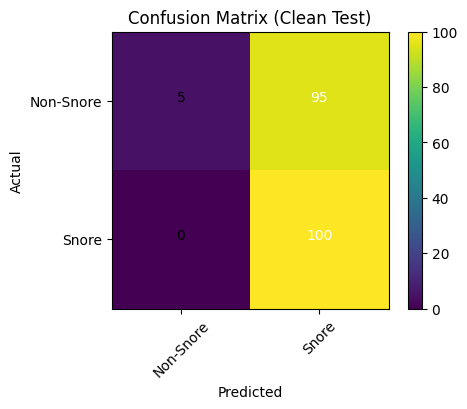

In [ ]:

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

probs = cnn.predict(X_te).ravel()
preds = (probs >= 0.5).astype(int)

print("=== Clean Test ===")
print(classification_report(y_te, preds, digits=4))
print("ROC-AUC:", roc_auc_score(y_te, probs))

cm = confusion_matrix(y_te, preds)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix (Clean Test)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Non-Snore','Snore'], rotation=45)
plt.yticks(tick_marks, ['Non-Snore','Snore'])
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()


Extracting log-mels (noise=True): 100%|██████████| 200/200 [00:50<00:00,  3.97it/s]


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step
=== Noisy Test ===
              precision    recall  f1-score   support

           0     0.7037    0.1900    0.2992       100
           1     0.5318    0.9200    0.6740       100

    accuracy                         0.5550       200
   macro avg     0.6177    0.5550    0.4866       200
weighted avg     0.6177    0.5550    0.4866       200

ROC-AUC (noisy): 0.5662999999999999


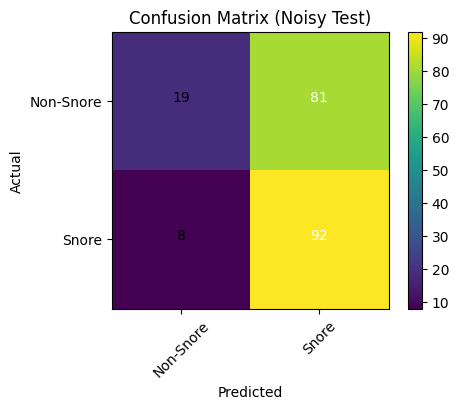

In [ ]:

# Evaluate on NOISY test (augmented at inference)
X_te_noisy = features_from_paths(X_te_paths, add_noise=True)
probs_n = cnn.predict(X_te_noisy).ravel()
preds_n = (probs_n >= 0.5).astype(int)

print("=== Noisy Test ===")
print(classification_report(y_te, preds_n, digits=4))
print("ROC-AUC (noisy):", roc_auc_score(y_te, probs_n))

cm_n = confusion_matrix(y_te, preds_n)
plt.figure(figsize=(5,4))
plt.imshow(cm_n, interpolation='nearest')
plt.title('Confusion Matrix (Noisy Test)')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Non-Snore','Snore'], rotation=45)
plt.yticks(tick_marks, ['Non-Snore','Snore'])
thresh = cm_n.max() / 2.
for i in range(cm_n.shape[0]):
    for j in range(cm_n.shape[1]):
        plt.text(j, i, format(cm_n[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm_n[i, j] > thresh else "black")
plt.tight_layout()
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.show()


In [ ]:

cnn.save("/content/drive/MyDrive/snore_end2end_cnn_no_yamnet.keras")
print("Saved model to Drive.")


Saved model to Drive.
